In [1]:
import numpy as np
import pandas as pd
import datetime
from sklearn import preprocessing
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/Explore-AI/Public-Data/master/Data/unsupervised_sprint/Live.csv')
df.head()

,status_id,status_type,status_published,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys,Column1,Column2,Column3,Column4
0,246675545449582_1649696485147474,video,4/22/2018 6:00,529,512,262,432,92,3,1,1,0,NaN,NaN,NaN,NaN
1,246675545449582_1649426988507757,photo,4/21/2018 22:45,150,0,0,150,0,0,0,0,0,NaN,NaN,NaN,NaN
2,246675545449582_1648730588577397,video,4/21/2018 6:17,227,236,57,204,21,1,1,0,0,NaN,NaN,NaN,NaN
3,246675545449582_1648576705259452,photo,4/21/2018 2:29,111,0,0,111,0,0,0,0,0,NaN,NaN,NaN,NaN
4,246675545449582_1645700502213739,photo,4/18/2018 3:22,213,0,0,204,9,0,0,0,0,NaN,NaN,NaN,NaN


In [3]:
print("Dataset with redundant columns......")
df.info()
df.drop(['Column1', 'Column2', 'Column3', 'Column4'], axis=1, inplace=True)
print("Dataset without reduntant columns.....")
df.info()

Dataset with redundant columns......
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7050 entries, 0 to 7049
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   status_id         7050 non-null   object 
 1   status_type       7050 non-null   object 
 2   status_published  7050 non-null   object 
 3   num_reactions     7050 non-null   int64  
 4   num_comments      7050 non-null   int64  
 5   num_shares        7050 non-null   int64  
 6   num_likes         7050 non-null   int64  
 7   num_loves         7050 non-null   int64  
 8   num_wows          7050 non-null   int64  
 9   num_hahas         7050 non-null   int64  
 10  num_sads          7050 non-null   int64  
 11  num_angrys        7050 non-null   int64  
 12  Column1           0 non-null      float64
 13  Column2           0 non-null      float64
 14  Column3           0 non-null      float64
 15  Column4           0 non-null      float64
dtypes: fl

In [4]:
# view how many different types of categories there are in the status_id column, if any
print("There are",len(df['status_id'].unique()),"unique labels in the status_id column")
# view how many different types of categories there are in the status_published column, if any
print("There are",len(df['status_published'].unique()),"unique labels in the status_published column")
# view how many different types of categories there are in the status_type column, if any
print("There are",len(df['status_type'].unique()), "unique labels in the status_id column")

There are 6997 unique labels in the status_id column
There are 6913 unique labels in the status_published column
There are 4 unique labels in the status_id column


In [5]:
df.drop(['status_id', 'status_published'], axis=1, inplace=True)

In [6]:
from sklearn.preprocessing import LabelEncoder
#Instantiate the encoder
le = LabelEncoder()
df['status_type'] = le.fit_transform(df['status_type'])
df

,status_type,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys
0,3,529,512,262,432,92,3,1,1,0
1,1,150,0,0,150,0,0,0,0,0
2,3,227,236,57,204,21,1,1,0,0
3,1,111,0,0,111,0,0,0,0,0
4,1,213,0,0,204,9,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
7045,1,89,0,0,89,0,0,0,0,0
7046,1,16,0,0,14,1,0,1,0,0
7047,1,2,0,0,1,1,0,0,0,0
7048,1,351,12,22,349,2,0,0,0,0


In [7]:
from sklearn.preprocessing import MinMaxScaler

ms = MinMaxScaler()

X_scaled = ms.fit_transform(df)

In [8]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=6, random_state=0)

kmeans.fit(X_scaled)

KMeans(n_clusters=6, random_state=0)

In [9]:
print(kmeans.cluster_centers_)

[[ 6.66666667e-01  6.21541972e-02  1.46110799e-03  6.95703724e-04
   6.15039452e-02  2.39896408e-03  3.30720498e-03  7.60528567e-04
   8.25285338e-03  8.66634569e-04]
 [ 3.29309354e-01  1.68648841e-02  6.24577384e-04  4.88990659e-04
   1.64533325e-02  1.66118999e-03  1.73165237e-03  1.07961705e-03
   2.85494834e-03  1.52588036e-03]
 [ 1.00000000e+00  3.71757948e-02  2.33386251e-02  2.45079066e-02
   3.14693670e-02  3.74459054e-02  2.43389050e-03  7.25514265e-03
   5.86496848e-03  5.14804389e-03]
 [ 4.12393162e-01  4.94083782e-01  3.43631277e-03  3.52339444e-03
   4.92472372e-01  6.45904071e-03  1.10680686e-02  1.55152703e-03
   5.02765209e-04 -9.10729825e-18]
 [ 1.00000000e+00  3.07527504e-01  1.14459139e-01  1.40491466e-01
   2.65879855e-01  2.46046281e-01  8.20220829e-02  5.48043189e-02
   3.40778022e-02  4.32982577e-02]
 [ 3.07843137e-01  2.40671912e-01  2.21281843e-03  4.97869709e-03
   2.38281504e-01  1.04396096e-02  1.34151502e-02  3.52191832e-03
   1.84544406e-03  7.59013283e-04

In [10]:
from sklearn.metrics import silhouette_score

# Calculate the silhouette score
silhouette_avg = silhouette_score(X_scaled, kmeans.labels_)

print("The average silhouette_score is :", silhouette_avg)

The average silhouette_score is : 0.7561086048749246


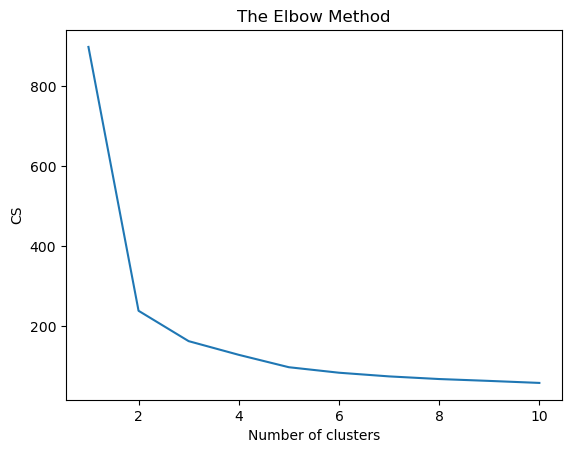

In [11]:
cs = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', max_iter = 300, n_init = 10, random_state = 0)
    kmeans.fit(X_scaled)
    cs.append(kmeans.inertia_)
plt.plot(range(1, 11), cs)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('CS')
plt.show()

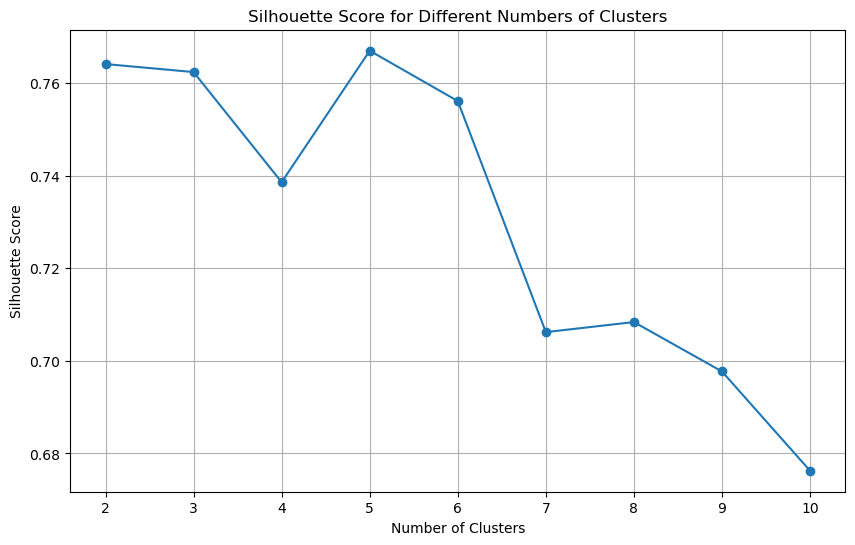

In [12]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import silhouette_score

# List to store silhouette scores
silhouette_scores = []

# Range of clusters to try
num_clusters_range = range(2, 11)

# Iterate over different numbers of clusters
for num_clusters in num_clusters_range:
    # Train KMeans model with num_clusters clusters
    kmeans = KMeans(n_clusters=num_clusters, random_state=0)
    kmeans.fit(X_scaled)

    # Calculate silhouette score
    silhouette_avg = silhouette_score(X_scaled, kmeans.labels_)
    silhouette_scores.append(silhouette_avg)

# Plotting silhouette scores
plt.figure(figsize=(10, 6))
plt.plot(num_clusters_range, silhouette_scores, marker='o', linestyle='-')
plt.title('Silhouette Score for Different Numbers of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.xticks(np.arange(min(num_clusters_range), max(num_clusters_range)+1, 1.0))
plt.grid(True)
plt.show()